In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#!unzip "/content/drive/MyDrive/Image_Representation_.zip" -d "/content/myproject"

In [5]:
# Helper functions

import os
import glob # library for loading images from a directory
import matplotlib.image as mpimg

import cv2



# This function loads in images and their labels and places them in a list
# The list contains all images and their associated labels
# For example, after data is loaded, im_list[0][:] will be the first image-label pair in the list
def load_dataset(image_dir):

    # Populate this empty image list
    im_list = []
    image_types = ["day", "night"]
    c = 0
    # Iterate through each color folder
    for im_type in image_types:

        # Iterate through each image file in each image_type folder
        # glob reads in any image with the extension "image_dir/im_type/*"
        for file in glob.glob(os.path.join(image_dir, im_type, "*")):

            # Read in the image
            im = mpimg.imread(file)

            # Check if the image exists/if it's been correctly read-in
            if not im is None:
                # Append the image, and it's type (red, green, yellow) to the image list
                im_list.append((im, im_type))
                c = c + 1
    print(c)

    return im_list



## Standardize the input images
# Resize each image to the desired input size: 600x1100px (hxw).

## Standardize the output
# With each loaded image, we also specify the expected output.
# For this, we use binary numerical values 0/1 = night/day.


# This function should take in an RGB image and return a new, standardized version
# 600 height x 1100 width image size (px x px)
def standardize_input(image):

    # Resize image and pre-process so that all "standard" images are the same size
    standard_im = cv2.resize(image, (1100, 600))

    return standard_im


# Examples:
# encode("day") should return: 1
# encode("night") should return: 0
def encode(label):

    numerical_val = 0
    if(label == 'day'):
        numerical_val = 1
    # else it is night and can stay 0

    return numerical_val

# using both functions above, standardize the input images and output labels
def standardize(image_list):

    # Empty image data array
    standard_list = []

    # Iterate through all the image-label pairs
    for item in image_list:
        image = item[0]
        label = item[1]

        # Standardize the image
        standardized_im = standardize_input(image)

        # Create a numerical label
        binary_label = encode(label)

        # Append the image, and it's one hot encoded label to the full, processed list of image data
        standard_list.append((standardized_im, binary_label))

    return standard_list

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

%matplotlib inline

In [7]:
image_dir_training = "/content/drive/MyDrive/Image_Representation_/day_night_images/training"
image_dir_test = "/content/drive/MyDrive/Image_Representation_/day_night_images/test"

In [8]:
IMAGE_LIST = load_dataset(image_dir_training)

240


Shape of image: (737, 1024, 3)
Image label: day


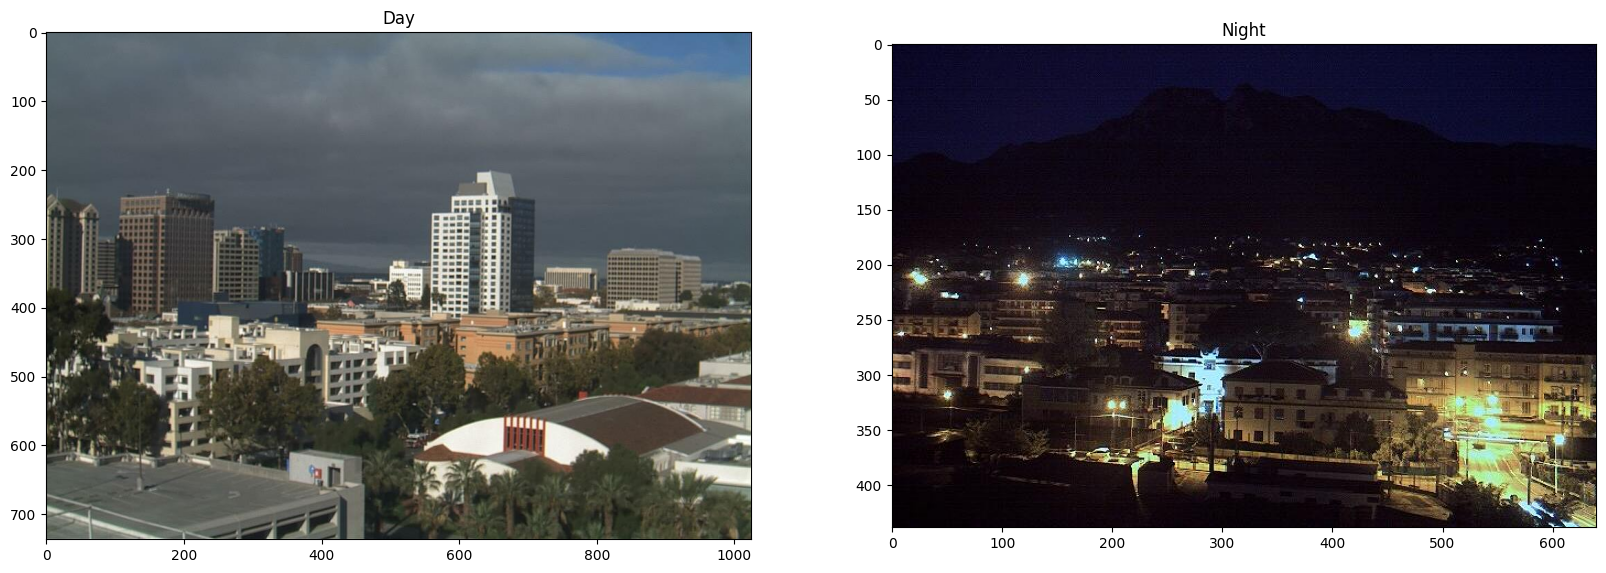

In [9]:
image_index = 0
selected_image = IMAGE_LIST[image_index][0]
selected_label = IMAGE_LIST[image_index][1]

# Print out 1. The shape of the image and 2. The image's label `selected_label`
print(f"Shape of image: {selected_image.shape}")
print(f"Image label: {selected_label}")

## Find first day image
for image_label_pair in IMAGE_LIST:
    if(image_label_pair[1] == "day"):
        image_day = image_label_pair[0]
        break

## Find first night image
for image_label_pair in IMAGE_LIST:
    if(image_label_pair[1] == "night"):
        image_night = image_label_pair[0]
        break

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))

ax1.set_title('Day')
ax1.imshow(image_day)

ax2.set_title('Night')
ax2.imshow(image_night)


In [10]:
# This function should take in an RGB image and return a new, standardized version
def standardize_input(image):

    # Resize image so that all "standard" images are the same size 600x1100 (hxw)
    standard_im = cv2.resize(image, dsize=(1100, 600), interpolation=cv2.INTER_CUBIC)
    return standard_im

In [11]:
def encode(label):
    if label == "day":
        numerical_val = 1
    elif label == "night":
        numerical_val = 0

    return numerical_val

In [12]:
def standardize(image_list):

    # Empty image data array
    standard_list = []

    # Iterate through all the image-label pairs
    for item in image_list:
        image = item[0]
        label = item[1]

        # Standardize the image
        standardized_im = standardize_input(image)

        # Create a numerical label
        binary_label = encode(label)

        # Append the image, and it's one hot encoded label to the full, processed list of image data
        standard_list.append((standardized_im, binary_label))

    return standard_list

# Standardize all training images
STANDARDIZED_LIST = standardize(IMAGE_LIST)

Shape: (600, 1100, 3)
Label [1 = day, 0 = night]: 0


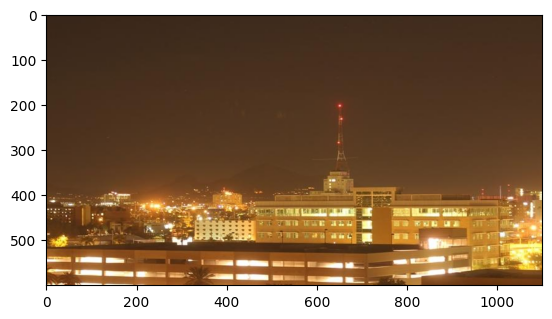

In [13]:
image_num = 130
selected_image = STANDARDIZED_LIST[image_num][0]
selected_label = STANDARDIZED_LIST[image_num][1]

# Display image and data about it
plt.imshow(selected_image)
print("Shape: "+str(selected_image.shape))
print("Label [1 = day, 0 = night]: " + str(selected_label))

Label: 1


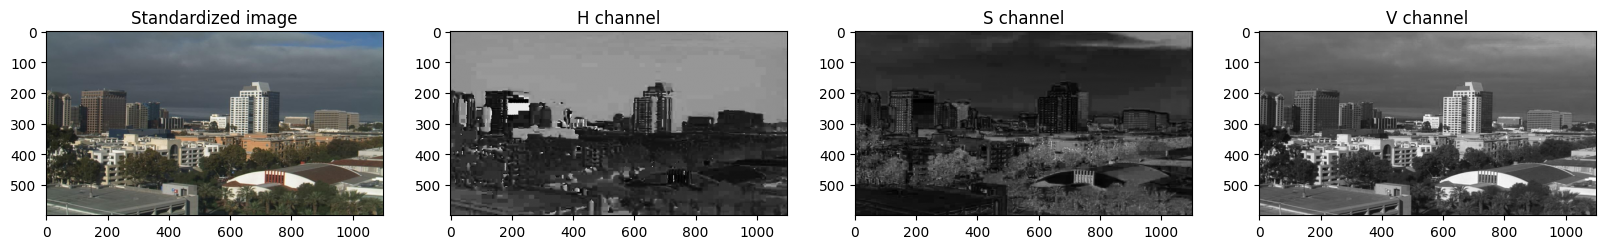

In [14]:
image_num = 0
test_im = STANDARDIZED_LIST[image_num][0]
test_label = STANDARDIZED_LIST[image_num][1]

# Convert to HSV
hsv = cv2.cvtColor(test_im, cv2.COLOR_RGB2HSV)

# Print image label
print('Label: ' + str(test_label))

# HSV channels
h = hsv[:,:,0]
s = hsv[:,:,1]
v = hsv[:,:,2]

# Plot the original image and the three channels
f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))
ax1.set_title('Standardized image')
ax1.imshow(test_im)
ax2.set_title('H channel')
ax2.imshow(h, cmap='gray')
ax3.set_title('S channel')
ax3.imshow(s, cmap='gray')
ax4.set_title('V channel')
ax4.imshow(v, cmap='gray')

In [15]:
def avg_brightness(rgb_image):

    # Convert image to HSV
    hsv = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)

    # Add up all the pixel values in the V channel
    sum_brightness = np.sum(hsv[:,:,2])

    # Calculate the average brightness using the area of the image
    height = rgb_image.shape[0]
    width = rgb_image.shape[1]
    area = height*width
    # and the sum calculated above
    avg = sum_brightness/area
    return avg

In [16]:
night_brightness = []
day_brightness = []

for image in STANDARDIZED_LIST:
    if image[1] == 0:
        night_brightness.append(avg_brightness(image[0]))
    elif image[1] == 1:
        day_brightness.append(avg_brightness(image[0]))

avg_day_brightness = np.mean(day_brightness)
avg_night_brightness = np.mean(night_brightness)
min_day_brightness = np.min(day_brightness)
max_day_brightness = np.max(day_brightness)
max_night_brightness = np.max(night_brightness)
min_night_brightness = np.min(night_brightness)
print(f"Average of average day brightness from: {avg_day_brightness}")
print(f"Average of average night brightness: {avg_night_brightness}")
print(f"Minimum day brightness: {min_day_brightness}")
print(f"Maximum day brightness: {max_day_brightness}")
print(f"Minimum night brightness: {min_night_brightness}")
print(f"Maximum night brightness: {max_night_brightness}")


Average of average day brightness from: 137.417367739899
Average of average night brightness: 69.26141393939393
Minimum day brightness: 94.67362121212122
Maximum day brightness: 200.09848636363637
Minimum night brightness: 8.160727272727273
Maximum night brightness: 119.6339


In [17]:
def colors_green_blue(rgb_image):
  hsv = cv2.cvtColor(rgb_image,cv2.COLOR_RGB2HSV)
  lower_hue = np.array([87,8,84])
  upper_hue = np.array([118,38,255])
  #lower_hue = np.array([90,0,0])
  #upper_hue = np.array([135,255,255])
  mask_hsv = cv2.inRange(hsv,lower_hue,upper_hue)
  # plt.imshow(mask_hsv)
  sum_color = np.sum(mask_hsv)
  height = rgb_image.shape[0]
  width = rgb_image.shape[1]
  area = height*width
  amount = ((sum_color / area)/255) * 100

  return amount

In [18]:
night_color = []
day_color = []

for image in STANDARDIZED_LIST:
    if image[1] == 0:
        night_color.append(colors_green_blue(image[0]))
    elif image[1] == 1:
        day_color.append(colors_green_blue(image[0]))


avg_day_brightness = np.mean(day_color)
avg_night_brightness = np.mean(night_color)
min_day_brightness = np.min(day_color)
max_day_brightness = np.max(day_color)
max_night_brightness = np.max(night_color)
min_night_brightness = np.min(night_color)

print(f"Average of average day color from: {avg_day_brightness}")
print(f"Average of average night color: {avg_night_brightness}")
print(f"Minimum day color: {min_day_brightness}")
print(f"Maximum day color: {max_day_brightness}")
print(f"Minimum night color: {min_night_brightness}")
print(f"Maximum night color: {max_night_brightness}")


Average of average day color from: 10.909045454545454
Average of average night color: 0.3488118686868687
Minimum day color: 0.895
Maximum day color: 58.636818181818185
Minimum night color: 0.0
Maximum night color: 3.2609090909090908


In [19]:
def estimate_label(rgb_image):

    avg = avg_brightness(rgb_image)
    amount = colors_green_blue(rgb_image)

    predicted_label = 0

    threshold = 94.67
    threshold2= 0.7

    if avg > threshold and amount > threshold2:
        predicted_label = 1



    return predicted_label

In [20]:
import random

# Using the load_dataset function in helpers.py
# Load test data
TEST_IMAGE_LIST = load_dataset(image_dir_test)

# Standardize the test data
STANDARDIZED_TEST_LIST = standardize(TEST_IMAGE_LIST)

# Shuffle the standardized test data
random.shuffle(STANDARDIZED_TEST_LIST)

160


In [21]:
def get_misclassified_images(test_images):
    misclassified_images_labels = []
    # Iterate through all the test images
    for image in test_images:
      im = image[0]
      true_label = image[1]
      predicted_label = estimate_label(im)

      if(predicted_label != true_label):
        misclassified_images_labels.append((im,predicted_label, true_label))

    # Classify each image and compare to the true label
        # Get true data
        # Get predicted label from your classifier
        # Compare true and predicted labels
            # If these labels are not equal, the image has been misclassified

    # Return the list of misclassified [image, predicted_label, true_label] values


    return misclassified_images_labels

In [22]:
MISCLASSIFIED = get_misclassified_images(STANDARDIZED_TEST_LIST)

total = len(STANDARDIZED_TEST_LIST)
num_correct = total - len(MISCLASSIFIED)
accuracy = num_correct/total

print('Accuracy: ' + str(accuracy))
print("Number of misclassified images = " + str(len(MISCLASSIFIED)) +' out of '+ str(total))

Accuracy: 0.99375
Number of misclassified images = 1 out of 160


Predicted: 0
True:1
4.014090909090909
93.2306696969697


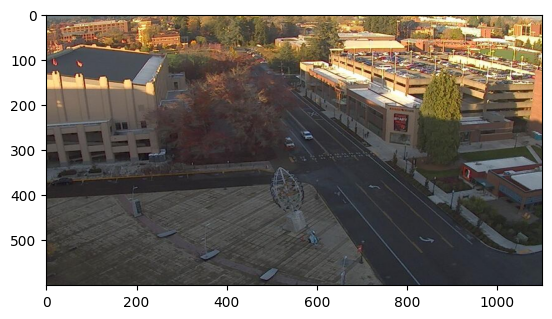

In [25]:
print(f"Predicted: {MISCLASSIFIED[0][1]}")
plt.imshow(MISCLASSIFIED[0][0])
print(f"True:{MISCLASSIFIED[0][2]}")
print(colors_green_blue(MISCLASSIFIED[0][0]))
print(avg_brightness(MISCLASSIFIED[0][0]))